# Training a supervised behaviour classifier
Annotation made in boris --> train --> supervised 

In [52]:
from pathlib import Path
from movement.io import load_dataset
from movement.filtering import rolling_filter
import pandas as pd
import xarray as xr
from movement.kinematics import compute_pairwise_distances
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from movement.kinematics import compute_forward_vector_angle
from movement.kinematics import compute_speed
from sklearn.ensemble import RandomForestClassifier

##  Load pose tracks and behaviour annotations

We start by loading the two pieces of data needed to train our classifier: the pose tracks and the behaviour annotations.

Let’s load the pose tracks into a movement dataset using load_dataset, as we did in Section 4.3.1.

In [2]:
# Adjust this path if your CalMS21 folder lives elsewhere
data_dir = Path.home() / "osss" / "CalMS21"

ds = load_dataset(
    data_dir / "mouse044_task1_annotator1.slp",
    fps=30,
)
ds

<xarray.Dataset> Size: 598kB
Dimensions:     (time: 3394, space: 2, keypoint: 7, individual: 2)
Coordinates:
  * time        (time) float64 27kB 0.0 0.03333 0.06667 ... 113.0 113.1 113.1
  * space       (space) <U1 8B 'x' 'y'
  * keypoint    (keypoint) <U9 252B 'nose' 'right_ear' ... 'tail_base'
  * individual  (individual) <U10 80B 'resident_b' 'intruder_w'
Data variables:
    position    (time, space, keypoint, individual) float32 380kB 854.4 ... 5...
    confidence  (time, keypoint, individual) float32 190kB nan nan ... nan nan
Attributes:
    source_software:  SLEAP
    ds_type:          poses
    fps:              30.0
    time_unit:        seconds
    source_file:      /Users/margotrefuge/osss/CalMS21/mouse044_task1_annotat...

Since these pose tracks were labelled by hand rather than predicted by a model, their confidence values are undefined (nan) for all frames. The upside is that the data quality is generally high, so we can skip most of the usual data cleaning steps. However, the tracks aren’t perfectly smooth: human annotators inevitably introduce small frame-to-frame jitter. To address this, we will apply a rolling median filter to the position data using rolling_filter.

In [5]:
ds.update(
  {"position": rolling_filter(ds.position, window=7, min_periods=2)}
)

Next, we load the manual BORIS annotations from the TSV file into a pandas DataFrame. The file uses the same BORIS export format described in Chapter 7, with one row per mount bout. We then select and display only the columns we are interested in, which include the start and stop times and frame indices of each mount bout.

In [14]:
boris_df = pd.read_csv(data_dir / "mouse044_task1_mount_events_boris.tsv", sep="\t")
columns_of_interest = [
    "Subject",
    "Behavior",
    "Start (s)",
    "Stop (s)",
    "Duration (s)",
    "Image index start",
    "Image index stop",
]
boris_df[columns_of_interest]

,Subject,Behavior,Start (s),Stop (s),Duration (s),Image index start,Image index stop
0,resident_b,mount,0.033,1.767,1.733,1,53
1,resident_b,mount,17.667,22.467,4.800,530,674
2,resident_b,mount,29.733,32.500,2.767,892,975
3,resident_b,mount,33.700,36.000,2.300,1011,1080
4,resident_b,mount,48.467,50.267,1.800,1454,1508
5,resident_b,mount,52.800,54.233,1.433,1584,1627
6,resident_b,mount,59.900,62.633,2.733,1797,1879
7,resident_b,mount,88.767,91.833,3.067,2663,2755
8,resident_b,mount,92.267,93.000,0.733,2768,2790
9,resident_b,mount,102.600,104.500,1.900,3078,3135


## Add per-frame behaviour labels

Using these ground-truth behaviour labels, we construct a per-frame boolean array, indicating whether a mount is occurring (True) or not (False) at each frame.

We store this boolean array in the dataset as a new data variable is_mount, alongside position and confidence, so that the behaviour labels and pose tracks live together in a single object.

This is_mount array serves as our vector of class labels, i.e. the ground truth for the classifier.

In [16]:
# Start with an all-False boolean array the size of dataset's time axis
ds["is_mount"] = xr.zeros_like(ds.time, dtype=bool)
ds["is_mount"]

<xarray.DataArray 'is_mount' (time: 3394)> Size: 3kB
False False False False False False ... False False False False False False
Coordinates:
  * time     (time) float64 27kB 0.0 0.03333 0.06667 0.1 ... 113.0 113.1 113.1

In [17]:

# Fill in True between start and stop frames for each BORIS bout
for _, ev in boris_df.iterrows():
  start, stop = ev["Image index start"], ev["Image index stop"]
  ds["is_mount"][start:stop] = True

ds.is_mount

ds

<xarray.Dataset> Size: 601kB
Dimensions:     (time: 3394, space: 2, keypoint: 7, individual: 2)
Coordinates:
  * time        (time) float64 27kB 0.0 0.03333 0.06667 ... 113.0 113.1 113.1
  * space       (space) <U1 8B 'x' 'y'
  * keypoint    (keypoint) <U9 252B 'nose' 'right_ear' ... 'tail_base'
  * individual  (individual) <U10 80B 'resident_b' 'intruder_w'
Data variables:
    position    (time, space, keypoint, individual) float32 380kB 858.4 ... 5...
    confidence  (time, keypoint, individual) float32 190kB nan nan ... nan nan
    is_mount    (time) bool 3kB False True True True ... False False False False
Attributes:
    source_software:  SLEAP
    ds_type:          poses
    fps:              30.0
    time_unit:        seconds
    source_file:      /Users/margotrefuge/osss/CalMS21/mouse044_task1_annotat...

Let’s calculate the fraction of frames that are labelled as mount.

Using mean : Computing a fraction involves counting how many entries satisfy a condition and dividing by the total number of entries. For boolean arrays, True is treated as 1 and False as 0, so the mean of a boolean array directly gives the fraction of True entries. In contrast, the sum would give the total number of True entries.

Class imbalance : We have much fewer mount frames than non-mount frames. This situation—often referred to as class imbalance—is quite common in behaviour classification scenarios.

In [18]:
mount_fraction = ds.is_mount.mean()
print(f"Mount frames: {mount_fraction.item():.2%}")

Mount frames: 20.57%


## Our first classifier: a distance threshold

What is the simplest classifier we could define, given the pose tracks for both mice?

One straightforward option could be to derive a single variable from the pose tracks that takes noticeably different values during mount vs non-mount periods.

For example, this could be the distance between the two mice’s centroids. During a mount, the resident is positioned directly on top of the intruder, so their centroids should be very close together.

We can compute this inter-mouse distance using the same approach introduced in Chapter 4.

Using the position data array of our dataset ds:

Compute centroid_pos, the trajectory of each mouse’s centroid using xarray.DataArray.mean. 
Hint: the centroid is the mean of all keypoints for a given mouse at each time frame.

Compute inter_mouse_distance, the distance between the two centroids using compute_pairwise_distances. 
Hint: specify "individual" as the dimension over which distances should be computed.

In [29]:
centroid_pos = ds.position.mean(dim="keypoint")
centroid_pos


<xarray.DataArray 'position' (time: 3394, space: 2, individual: 2)> Size: 54kB
794.1 780.9 394.7 456.8 794.1 782.0 ... 160.9 443.5 276.0 875.7 160.5 443.5
Coordinates:
  * time        (time) float64 27kB 0.0 0.03333 0.06667 ... 113.0 113.1 113.1
  * space       (space) <U1 8B 'x' 'y'
  * individual  (individual) <U10 80B 'resident_b' 'intruder_w'
Attributes:
    log:      [\n  {\n    "operation": "rolling_filter",\n    "datetime": "20...

In [34]:
inter_mouse_distance = compute_pairwise_distances(
    centroid_pos,
    dim="individual",
    pairs={"resident_b": "intruder_w"},
)
inter_mouse_distance



<xarray.DataArray 'distance' (time: 3394)> Size: 27kB
63.44 62.85 62.37 62.23 61.93 61.3 59.01 ... 649.8 656.5 659.4 662.5 662.6 663.1
Coordinates:
  * time     (time) float64 27kB 0.0 0.03333 0.06667 0.1 ... 113.0 113.1 113.1
Attributes:
    log:      [\n  {\n    "operation": "rolling_filter",\n    "datetime": "20...

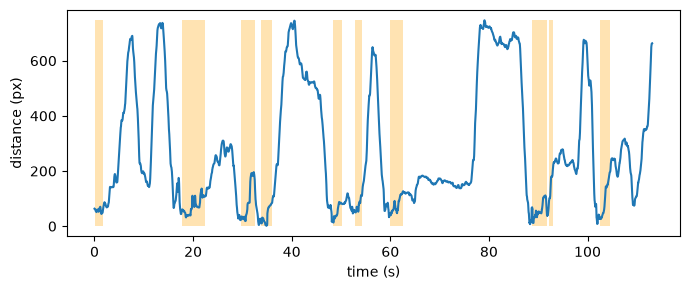

In [35]:
def plot_over_time(data_array, mount, ylabel, ymax=None):
    """Plot a per-frame quantity over time, with mount frames highlighted.

    ``mount`` is a boolean array (aligned to ``data_array``'s time axis) marking
    the frames to shade.
    """
    ymax = float(data_array.max()) if ymax is None else ymax
    plt.figure(figsize=(7, 3))
    plt.plot(data_array.time, data_array)
    plt.fill_between(
        data_array.time,
        0,
        ymax,
        where=mount,
        color="orange",
        edgecolor=None,
        alpha=0.3,
    )
    plt.xlabel("time (s)")
    plt.ylabel(ylabel)
    plt.tight_layout()
    plt.show()


plot_over_time(inter_mouse_distance, ds.is_mount, ylabel="distance (px)")

In [36]:
distance_threshold = 100  # pixels

ds["predicted_mount"] = inter_mouse_distance < distance_threshold
ds.predicted_mount

<xarray.DataArray 'predicted_mount' (time: 3394)> Size: 3kB
True True True True True True True ... False False False False False False False
Coordinates:
  * time     (time) float64 27kB 0.0 0.03333 0.06667 0.1 ... 113.0 113.1 113.1
Attributes:
    log:      [\n  {\n    "operation": "rolling_filter",\n    "datetime": "20...

# scikit-learn

This single rule already counts as a “classifier”, even if it’s a rather crude one.

To evaluate how well it performs, we can compare its predictions against the ground-truth labels. A confusion matrix is a convenient way to do this: it summarises, in a table, how many frames fall into each combination of predicted vs. ground-truth class.

To visualise this, we use scikit-learn’s ConfusionMatrixDisplay, which plots the matrix from our predicted and ground-truth labels. By default, the cells contain the raw frame counts for each predicted/ground-truth combination. With normalize="true", each row is scaled by its total, so every cell shows the percentage of frames relative to the total number of frames for that ground-truth class.

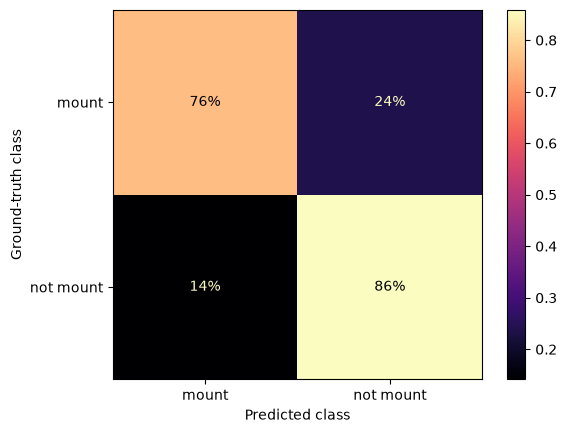

In [38]:
disp = ConfusionMatrixDisplay.from_predictions(
    ds.is_mount.values,
    ds.predicted_mount.values,
    labels=[True, False],  # mount first
    display_labels=["mount", "not mount"],
    normalize="true",      # normalise over each true-class row
    values_format=".0%",
    cmap="magma",
)
disp.ax_.set_xlabel("Predicted class")
disp.ax_.set_ylabel("Ground-truth class")
plt.show()

We can see that 76% of the frames that were manually labelled as mount were also classified as mount with our simple threshold-based classifier. The remaining 24% of the true mount frames were classified incorrectly as “non-mount”.

To further inspect these results we can compute a few more evaluation metrics using scikit-learn’s classification_report, which calculates precision, recall and F1-score for each class.

In [40]:
print(classification_report(
    ds.is_mount.values,
    ds.predicted_mount.values,
    labels=[True, False],  # mount first
    target_names=["mount", "not mount"],
))

              precision    recall  f1-score   support

       mount       0.58      0.76      0.66       698
   not mount       0.93      0.86      0.89      2696

    accuracy                           0.84      3394
   macro avg       0.76      0.81      0.78      3394
weighted avg       0.86      0.84      0.85      3394



All metrics are built from just four counts, obtained by comparing predictions and ground truth. Taking mount as the “positive” class:

Predicted mount	Predicted non-mount
Actual mount	TP (true positive)	FN (false negative)
Actual non-mount	FP (false positive)	TN (true negative)
These are exactly the four cells of the confusion matrix above. From these counts we can compute the following metrics:

Precision: of all frames predicted as mount, what fraction of them really was mount?
Precision=
𝑇⁢𝑃
𝑇⁢𝑃+𝐹⁡𝑃 


Recall: of all frames manually labelled as mount frames, what fraction did we predict correctly?
Recall=
𝑇⁢𝑃
𝑇⁢𝑃+𝐹⁡𝑁 


F1 score: the harmonic mean of precision and recall; high only when both are high.
𝐹1=2⋅
Precision⋅Recall
Precision+Recall 
=
2𝑇⁢𝑃
2𝑇⁢𝑃+𝐹⁡𝑃+𝐹⁡𝑁 


Accuracy: considering all frames, what fraction was classified correctly? Unlike the metrics above, it is a single number for the whole dataset rather than one per class, so it is easily inflated when one class dominates.
Accuracy=
𝑇⁢𝑃+𝑇⁢𝑁
𝑇⁢𝑃+𝑇⁢𝑁+𝐹⁡𝑃+𝐹⁡𝑁 


Support: refers to the number of frames that truly belong to each class (mount: 𝑇⁢𝑃 +𝐹⁡𝑁; non-mount: 𝑇⁢𝑁 +𝐹⁡𝑃). It tells us how much data each row’s metrics are based on.

Macro average: refers to the unweighted mean of the two class rows (e.g. (0.58 + 0.93)/2 for precision). Every class counts equally regardless of its size, so the rare mount class gets equal say. This is usually considered an honest summary in an imbalanced problem.

Weighted average: refers to the mean of the metric weighted by the size of the class. Big classes dominate, so it tracks accuracy closely (0.84 vs 0.84 here) and hides poor performance on the rare class.
Focusing on the mount class:

Precision ≈ 0.58: more than 40% of frames flagged as mount are false alarms.
Recall ≈ 0.76: the distance rule misses about 1/4 of all true mount frames.
F1 ≈ 0.66: a convenient single-number summary that balances the two types of mistakes.
Overall, we get an accuracy of about 0.84, meaning our classifier predicts 84% of frames correctly. But note this can be misleading in an imbalanced dataset like ours. Since only ~21% of frames are classified as mount, a classifier that always predicts not mount would already be right ~79% of the time, even if it predicted incorrectly all mount frames. This is why for imbalanced datasets, precision, recall and F1 are more informative than accuracy alone.

Tip

# 8.3 Exercices 

Create a boolean mask representing a hand-crafted decision tree that predicts mount only when all three of the following conditions hold:

the mice are close: inter_mouse_distance below 100 px,
the intruder is facing away from the resident: intruder_facing_resident_angle above 90°,
the resident is relatively still: resident_speed below 200 px/s.
Store the result in predicted_mount_tree, then evaluate it against the ground truth ds.is_mount with a confusion matrix and a classification report, like we did for the distance-only classifier.

Hint: you can combine boolean data arrays with the & (“and”) operator. Remember to wrap each comparison in parentheses.

In [46]:
resident_c = centroid_pos.sel(individual="resident_b")  # resident centroid
intruder_c = centroid_pos.sel(individual="intruder_w")  # intruder centroid
intruder_to_resident_vector = resident_c - intruder_c

In [47]:
# angle_mouse 
intruder_facing_resident_angle = compute_forward_vector_angle(
    data=ds.position.sel(individual="intruder_w"),  # all intruder keypoints,
    left_keypoint="left_ear",
    right_keypoint="right_ear",
    camera_view="top_down",
    reference_vector=intruder_to_resident_vector,
    in_degrees=True
)

intruder_facing_resident_angle

intruder_facing_resident_angle = abs(intruder_facing_resident_angle)


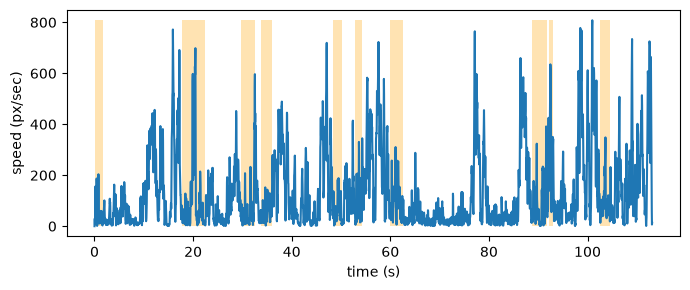

In [50]:
# speed 

resident_speed = compute_speed(resident_c)
resident_speed

def plot_over_time(data_array, mount, ylabel, ymax=None):
    """Plot a per-frame quantity over time, with mount frames highlighted.

    ``mount`` is a boolean array (aligned to ``data_array``'s time axis) marking
    the frames to shade.
    """
    ymax = float(data_array.max()) if ymax is None else ymax
    plt.figure(figsize=(7, 3))
    plt.plot(data_array.time, data_array)
    plt.fill_between(
        data_array.time,
        0,
        ymax,
        where=mount,
        color="orange",
        edgecolor=None,
        alpha=0.3,
    )
    plt.xlabel("time (s)")
    plt.ylabel(ylabel)
    plt.tight_layout()
    plt.show()


plot_over_time(resident_speed,ds.is_mount, ylabel="speed (px/sec)")

In [ ]:
# bool : close or no 

ds["dist_mouse"] = xr.zeros_like(ds.time, dtype=bool)

ds["angle_mouse"] = xr.zeros_like(ds.time, dtype=bool)

ds["speed_mouse"] = xr.zeros_like(ds.time, dtype=bool)

In [ ]:
# Fill in True if dist < 100 px 

inter_mouse_distance < 100

intruder_facing_resident_angle > 90

resident_speed > 200 



# RF

In [51]:


# Define feature matrix `X`: one row per frame, one column per feature
X = pd.DataFrame({
    "inter_mouse_distance": inter_mouse_distance.values,
    "intruder_facing_resident_angle": intruder_facing_resident_angle.values,
    "resident_speed": resident_speed.values,
})

# Define label vector `y`. The label vector holds the ground-truth, 
# i.e. the manual behaviour labels per frame.
y = ds.is_mount.values

# Set number of samples in training split
split = int(0.7 * len(X))

# Extract training set
X_train, X_val = X.iloc[:split], X.iloc[split:]

# Extract validation set
y_train, y_val = y[:split], y[split:]

print(f"Train:      {len(X_train)} frames ({y_train.sum()} mount)")
print(f"Validation: {len(X_val)} frames ({y_val.sum()} mount)")

Train:      2375 frames (527 mount)
Validation: 1019 frames (171 mount)


In [53]:
clf = RandomForestClassifier(class_weight="balanced", random_state=0)
clf.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",0
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1

In [54]:
y_pred = clf.predict(X_val)

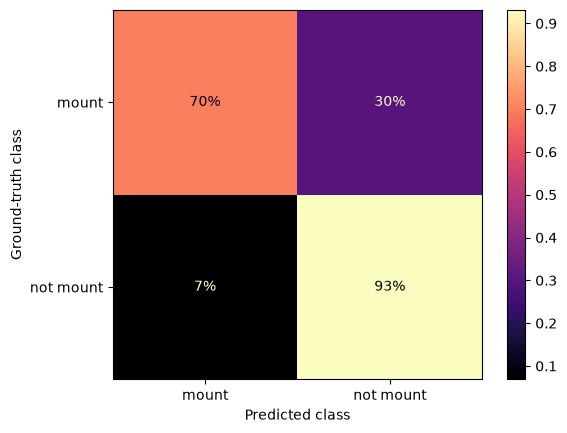

In [55]:
disp = ConfusionMatrixDisplay.from_predictions(
    y_val, y_pred,
    labels=[True, False],
    display_labels=["mount", "not mount"],
    normalize="true",
    values_format=".0%",
    cmap="magma",
)
disp.ax_.set_xlabel("Predicted class")
disp.ax_.set_ylabel("Ground-truth class")
plt.show()

In [56]:
print(classification_report(
    y_val,
    y_pred,
    labels=[True, False],
    target_names=["mount", "not mount"],
))

              precision    recall  f1-score   support

       mount       0.67      0.70      0.69       171
   not mount       0.94      0.93      0.94       848

    accuracy                           0.89      1019
   macro avg       0.81      0.82      0.81      1019
weighted avg       0.89      0.89      0.89      1019



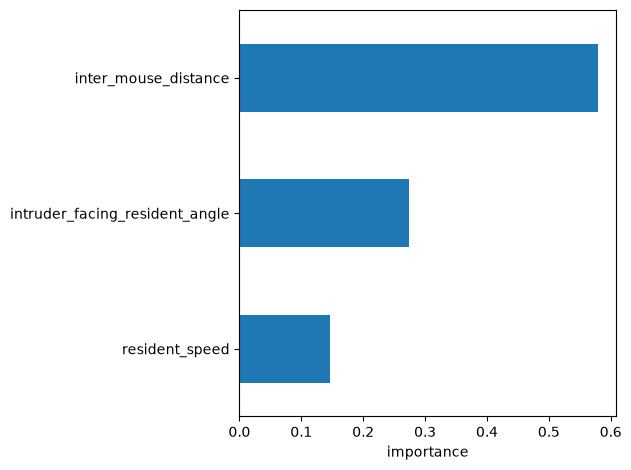

In [57]:
importances = pd.Series(
    clf.feature_importances_,
    index=X.columns,
).sort_values()

importances.plot.barh()
plt.xlabel("importance")
plt.tight_layout()
plt.show()

# Other video 

In [61]:
def compute_features(slp_name, tsv_name):
    """Run the full pipeline for one video and return the movement dataset, X and y."""
    # Load pose tracks and smooth them
    ds = load_dataset(data_dir / slp_name, source_software="SLEAP", fps=30)
    ds.update({"position": rolling_filter(ds.position, window=7, min_periods=2)})

    # Expand BORIS bouts into per-frame labels
    boris_df = pd.read_csv(data_dir / tsv_name, sep="\t")
    ds["is_mount"] = xr.zeros_like(ds.time, dtype=bool)
    for _, ev in boris_df.iterrows():
        ds["is_mount"][ev["Image index start"]:ev["Image index stop"]] = True

    # Compute the three features
    centroid_pos = ds.position.mean("keypoint")
    inter_mouse_distance = compute_pairwise_distances(
        centroid_pos, dim="individual", pairs={"resident_b": "intruder_w"}
    )
    resident_c = centroid_pos.sel(individual="resident_b")
    intruder_c = centroid_pos.sel(individual="intruder_w")
    angle = abs(compute_forward_vector_angle(
        data=ds.position.sel(individual="intruder_w"),
        left_keypoint="left_ear",
        right_keypoint="right_ear",
        camera_view="top_down",
        reference_vector=resident_c - intruder_c,
        in_degrees=True,
    ))
    resident_speed = compute_speed(resident_c)

    X = pd.DataFrame({
        "inter_mouse_distance": inter_mouse_distance.values,
        "intruder_facing_resident_angle": angle.values,
        "resident_speed": resident_speed.values,
    })
    y = ds.is_mount.values
    return ds, X, y

ds_new, X_new, y_new = compute_features(
    slp_name="mouse026_task1_annotator1.slp",
    tsv_name="mouse026_task1_mount_events_boris.tsv",
)

print(f"Ground-truth labels in new video: {len(y_new)} frames ({y_new.mean():.1%} mount)")

print(classification_report(
    y_new,
    y_new_pred,
    labels=[True, False],  # mount first
    target_names=["mount", "not mount"],
))

Ground-truth labels in new video: 3632 frames (29.8% mount)


NameError: name 'y_new_pred' is not defined

# From frame predictions to behaviour bouts

Our model classifies each frame independently, so its predictions flicker: a few stray non-mount frames may split a single mount bout into fragments, and vice-versa. We can observe this by counting contiguous runs of predicted mount frames and comparing them with the ground-truth bouts.

Code
Predicted mount bouts:    87
Ground-truth mount bouts: 11

The model produces substantially more bouts than are actually present. Since the mount behaviour unfolds over a much longer timescale than a single frame (just as we annotated it using BORIS in Chapter 7), we can try to smooth the predictions in time.

The idea is to assign each frame’s label by taking a majority vote over a small moving window, so isolated flips get “overruled” by their neighbours. We can do this with the same rolling_filter we used for the pose tracks, using the median as the statistic: over a window of 0s and 1s, the median sets a frame as mount only if most frames in the window are also classified as mount—a direct majority vote.

Note that with an even-sized window, the vote can tie. In that case the median is 0.5. We can resolve ties by rounding the output with .round, which follows NumPy’s convention of rounding halves to the nearest even number (so 0.5 becomes 0, i.e.non-mount).

The filter operates on time-aware movement arrays, so we first wrap y_new_pred as a DataArray along the same time axis.

Smooth the per-frame predictions using rolling_filter, store the result in y_new_smoothed, and count its bouts using the count_bouts function.

Use a window of 30 frames (~1 s at 30 fps) and:

Set statistic="median", to get the majority vote described above.
Set min_periods=1, so the edges of the array are kept instead of being padded with NaNs.
Convert the result back to a boolean mask. Hint: the filter treats the input boolean data as 0s and 1s and always returns floats (decimal numbers). Also, before casting to booleans with .astype(bool), you will need to round the output to resolve ties (0.5).
How does the resulting number of bouts compare to the ground truth?

In [60]:
# Wrap the predictions as a DataArray on the time axis so movement can filter them
y_new_pred = xr.DataArray(
    y_new_pred, coords={"time": ds_new.time}, dims="time"
)

NameError: name 'y_new_pred' is not defined

In [ ]:
fig, ax = plt.subplots(figsize=(7, 2))
rows = [
    ("ground truth", y_new, "tab:green"),
    ("raw predicted", y_new_pred, "tab:gray"),
    ("smooth predicted", y_new_smoothed, "tab:orange"),
]
for i, (label, mask, color) in enumerate(rows):
    ax.fill_between(ds_new.time, i, i + 0.8, where=mask, color=color, step="mid")

ax.set_yticks([i + 0.4 for i in range(len(rows))])
ax.set_yticklabels([label for label, _, _ in rows])
ax.invert_yaxis()  # first row on top
ax.set_xlabel("time (s)")
plt.tight_layout()
plt.show()

NameError: name 'y_new_pred' is not defined